In [10]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ===============================
# STEP 1: LOAD DATASET
# ===============================
df = pd.read_csv("student_ml_dataset.csv")

print("Dataset Preview:\n")
print(df.head())

Dataset Preview:

   student_id  weekly_self_study_hours  attendance_percentage  \
0           1                        5                     70   
1           2                        8                     85   
2           3                        2                     60   
3           4                       10                     90   
4           5                        6                     75   

   class_participation  previous_score  total_score grade  
0                    6              55           60     C  
1                    8              65           75     B  
2                    4              40           45     D  
3                    9              75           88     A  
4                    7              60           68     B  


In [11]:
# ==========================
# STEP 2: FEATURES
# ==========================
features = [
    'weekly_self_study_hours',
    'attendance_percentage',
    'class_participation',
    'previous_score',
    'total_score'
]

X = df[features]

# Target = Grade
y = df["grade"]

# ==========================
# STEP 3: SPLIT DATA
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ==========================
# STEP 4: CREATE MODEL
# ==========================
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=8,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

# ==========================
# STEP 5: TRAIN MODEL
# ==========================
model.fit(X_train, y_train)

# ==========================
# STEP 6: PREDICTION
# ==========================
y_pred = model.predict(X_test)

# ==========================
# STEP 7: EVALUATION
# ==========================
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           A       1.00      1.00      1.00         2
           B       1.00      1.00      1.00         2
           C       1.00      1.00      1.00         1
           D       1.00      1.00      1.00         1

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



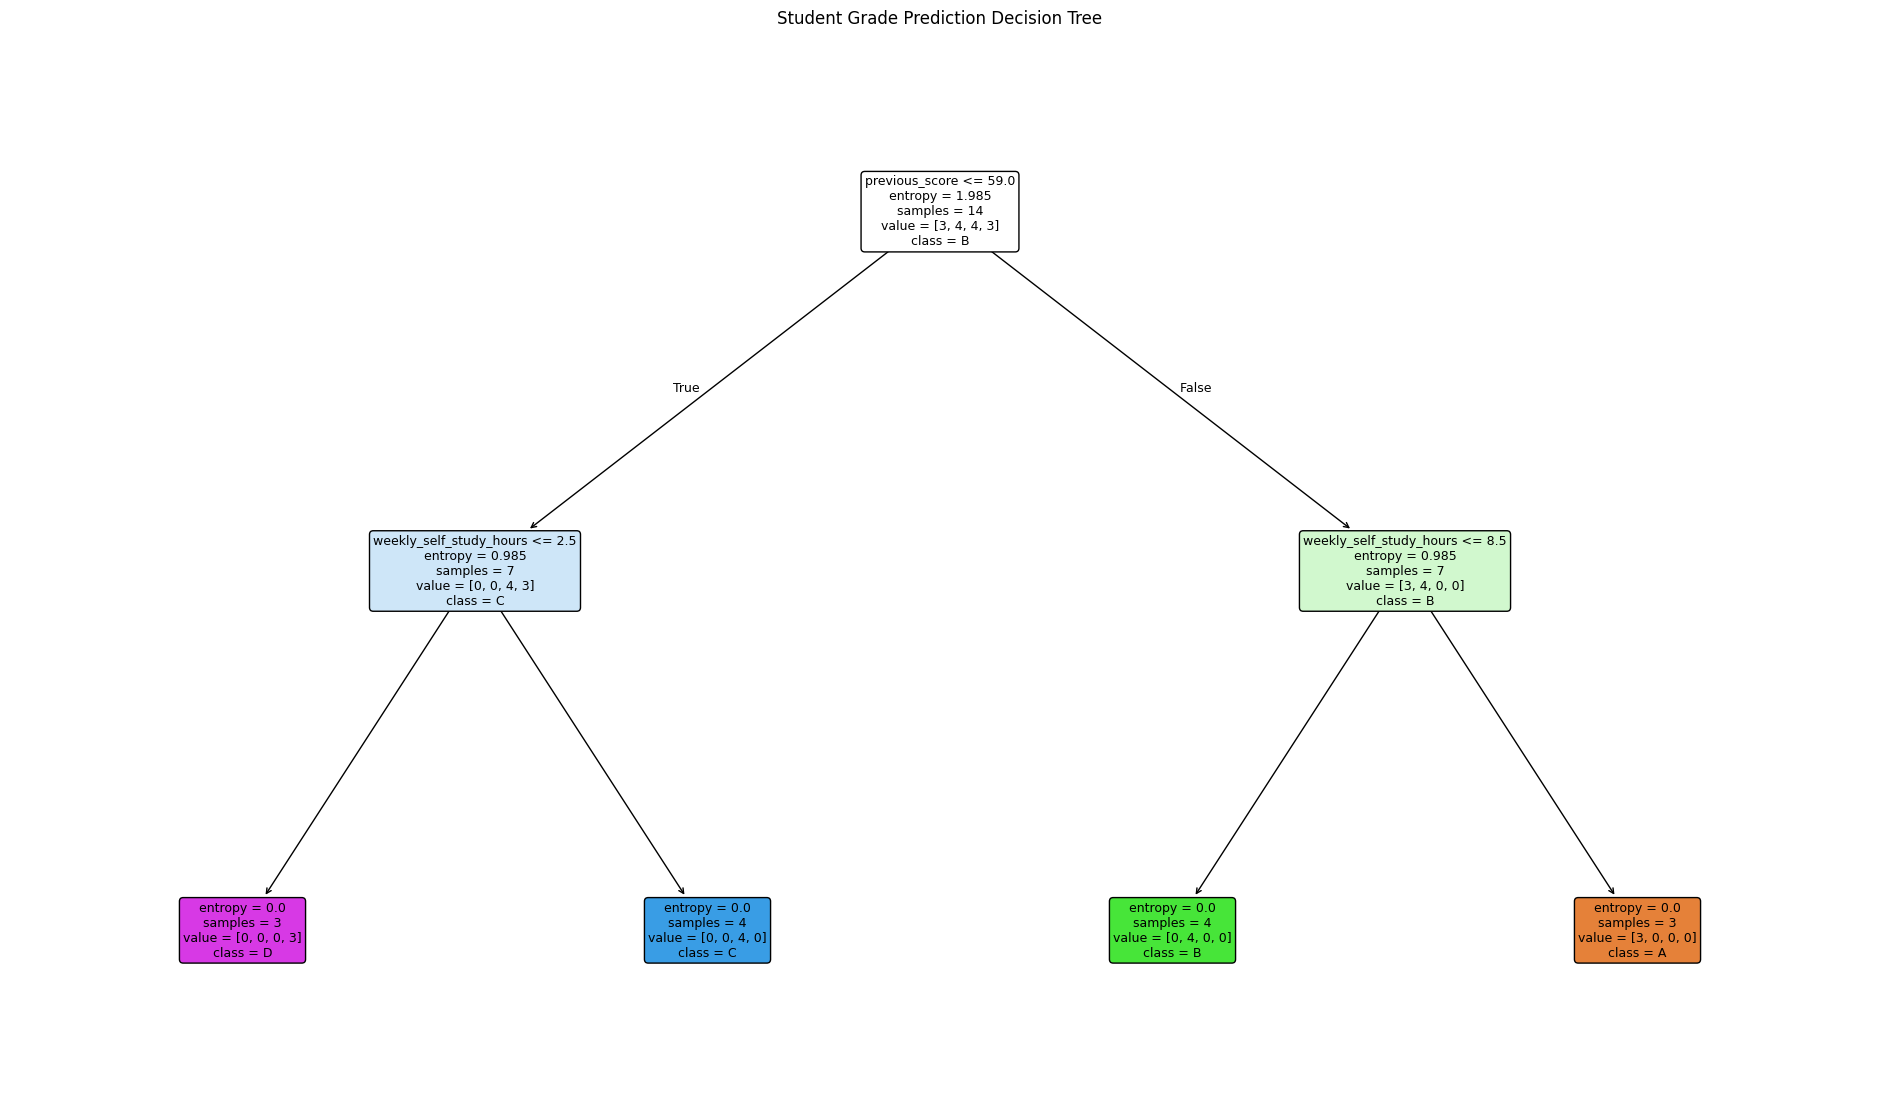

In [12]:
# ==========================
# STEP 8: TREE GRAPH
# ==========================
plt.figure(figsize=(24,14))

plot_tree(
    model,
    feature_names=features,
    class_names=model.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Student Grade Prediction Decision Tree")
plt.show()